# 03b — EDA: Downside Depegs
Exploratory analysis scoped to **below-peg** events only (`price_dev < -0.5%` for ≥3 consecutive bars).
Upside depegs (price above peg) are excluded throughout.

| # | Notebook | Reads → Writes |
|---|----------|----------------|
| 01 | Merge Raw Data | `raw/` → `merged/{coin}_5m_raw.parquet` |
| 02 | Clean & Label | `merged/` → `cleansed/{coin}_5m.parquet` |
| 03 | EDA | `cleansed/` |
| **▶ 03b** | **EDA — Downside Depegs** | `cleansed/` |
| 04 | Feature Engineering | `cleansed/` → `features/{coin}_5m_features.parquet` |
| 05 | Build Pooled Dataset | `features/` → `features/pooled_5m.parquet` |
| 06 | Feature-Level EDA | `features/pooled_5m.parquet` |
| 07 | Feature Selection | `features/pooled_5m.parquet` → `features/selected_features.json` |
| 08 | Baseline Models | `features/pooled_5m.parquet` + `selected_features.json` → model results |
| 09 | Final Model (CatBoost) | + `selected_features.json` → `data/models/downside_depeg_catboost.cbm` + `downside_depeg_meta.json` |
| 10 | Threshold & Ops | `data/models/downside_depeg_meta.json` → threshold, alert metrics |
| 11 | LOEO Validation | `data/models/downside_depeg_meta.json` → leave-one-event-out results |

In [1]:
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ── Environment detection ─────────────────────────────────────────────────────
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    print("Running in Google Colab — Drive mounted at /content/drive")
else:
    print("Running locally")

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.3})

Running locally


In [2]:
DRIVE_PROJECT_PATH = "MyDrive/Capstone"   # ← Colab: path inside Google Drive
LOCAL_PROJECT_PATH = None                               # ← Local: set explicit path or None for auto-detect

if IN_COLAB:
    ROOT = Path("/content/drive") / DRIVE_PROJECT_PATH
elif LOCAL_PROJECT_PATH is not None:
    ROOT = Path(LOCAL_PROJECT_PATH)
else:
    _candidates = [Path.cwd()] + list(Path.cwd().parents)
    ROOT = next((p for p in _candidates if (p / "config" / "settings.py").exists()), None)
    if ROOT is None:
        raise FileNotFoundError(
            "Could not find project root (looked for config/settings.py). "
            "Set LOCAL_PROJECT_PATH above or run from within the project directory."
        )

os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

CLEANSED_DIR = ROOT / "data" / "processed" / "cleansed"

COINS  = ['usdt', 'usdc', 'dai', 'busd', 'ust', 'usde', 'rlusd']
COLORS = {'usdt': '#26A17B', 'usdc': '#2775CA', 'dai': '#F5AC37',
          'busd': '#F0B90B', 'ust':  '#E84142', 'usde': '#9B59B6', 'rlusd': '#00AAE4'}

print(f"Project root:  {ROOT}")
print(f"Cleansed dir:  {CLEANSED_DIR}")

Project root:  /Users/robertspringett/Education/CMU_MSBA/capstone_5min_global
Cleansed dir:  /Users/robertspringett/Education/CMU_MSBA/capstone_5min_global/data/processed/cleansed


## 1. Dataset Overview — Downside Depeg Rates

In [3]:
rows = []
dfs  = {}
for coin in COINS:
    df = pd.read_parquet(CLEANSED_DIR / f'{coin}_5m.parquet')
    dfs[coin] = df
    depeg_down_rate = df['depeg_down'].mean() if 'depeg_down' in df.columns else float('nan')
    depeg_rate      = df['depeg'].mean()      if 'depeg'      in df.columns else float('nan')
    rows.append({
        'Coin'              : coin.upper(),
        'Rows'              : f'{len(df):,}',
        'Start'             : str(df.index.min().date()),
        'End'               : str(df.index.max().date()),
        'Depeg Rate (all)'  : f'{depeg_rate:.2%}',
        'Depeg Down Rate'   : f'{depeg_down_rate:.2%}',
        'Down Hours'        : f"{(df['depeg_down']==1).sum()*5/60:.0f}h" if 'depeg_down' in df.columns else '—',
        'Down / All'        : f"{depeg_down_rate/depeg_rate:.0%}" if depeg_rate > 0 else '—',
    })

pd.DataFrame(rows).set_index('Coin').style\
    .set_caption("Downside depeg rate vs overall depeg rate")\
    .set_table_styles([{"selector": "th", "props": [("background-color", "#1A2E4A"), ("color", "white")]}])

,Rows,Start,End,Depeg Rate (all),Depeg Down Rate,Down Hours,Down / All
Coin,,,,,,,
USDT,"897,936",2017-08-17,2026-02-28,9.12%,2.72%,2034h,30%
USDC,"775,506",2018-10-16,2026-02-28,5.59%,0.19%,125h,3%
DAI,"828,963",2018-04-13,2026-02-28,10.67%,1.95%,1348h,18%
BUSD,"370,848",2019-09-20,2023-03-31,0.28%,0.00%,0h,0%
UST,"153,961",2020-11-23,2022-05-12,5.31%,1.97%,253h,37%
USDE,"200,928",2024-04-02,2026-02-28,0.05%,0.04%,7h,96%
RLUSD,"96,192",2025-04-01,2026-02-28,0.00%,0.00%,0h,—


## 2. Price Deviation — Below-Peg Events Highlighted

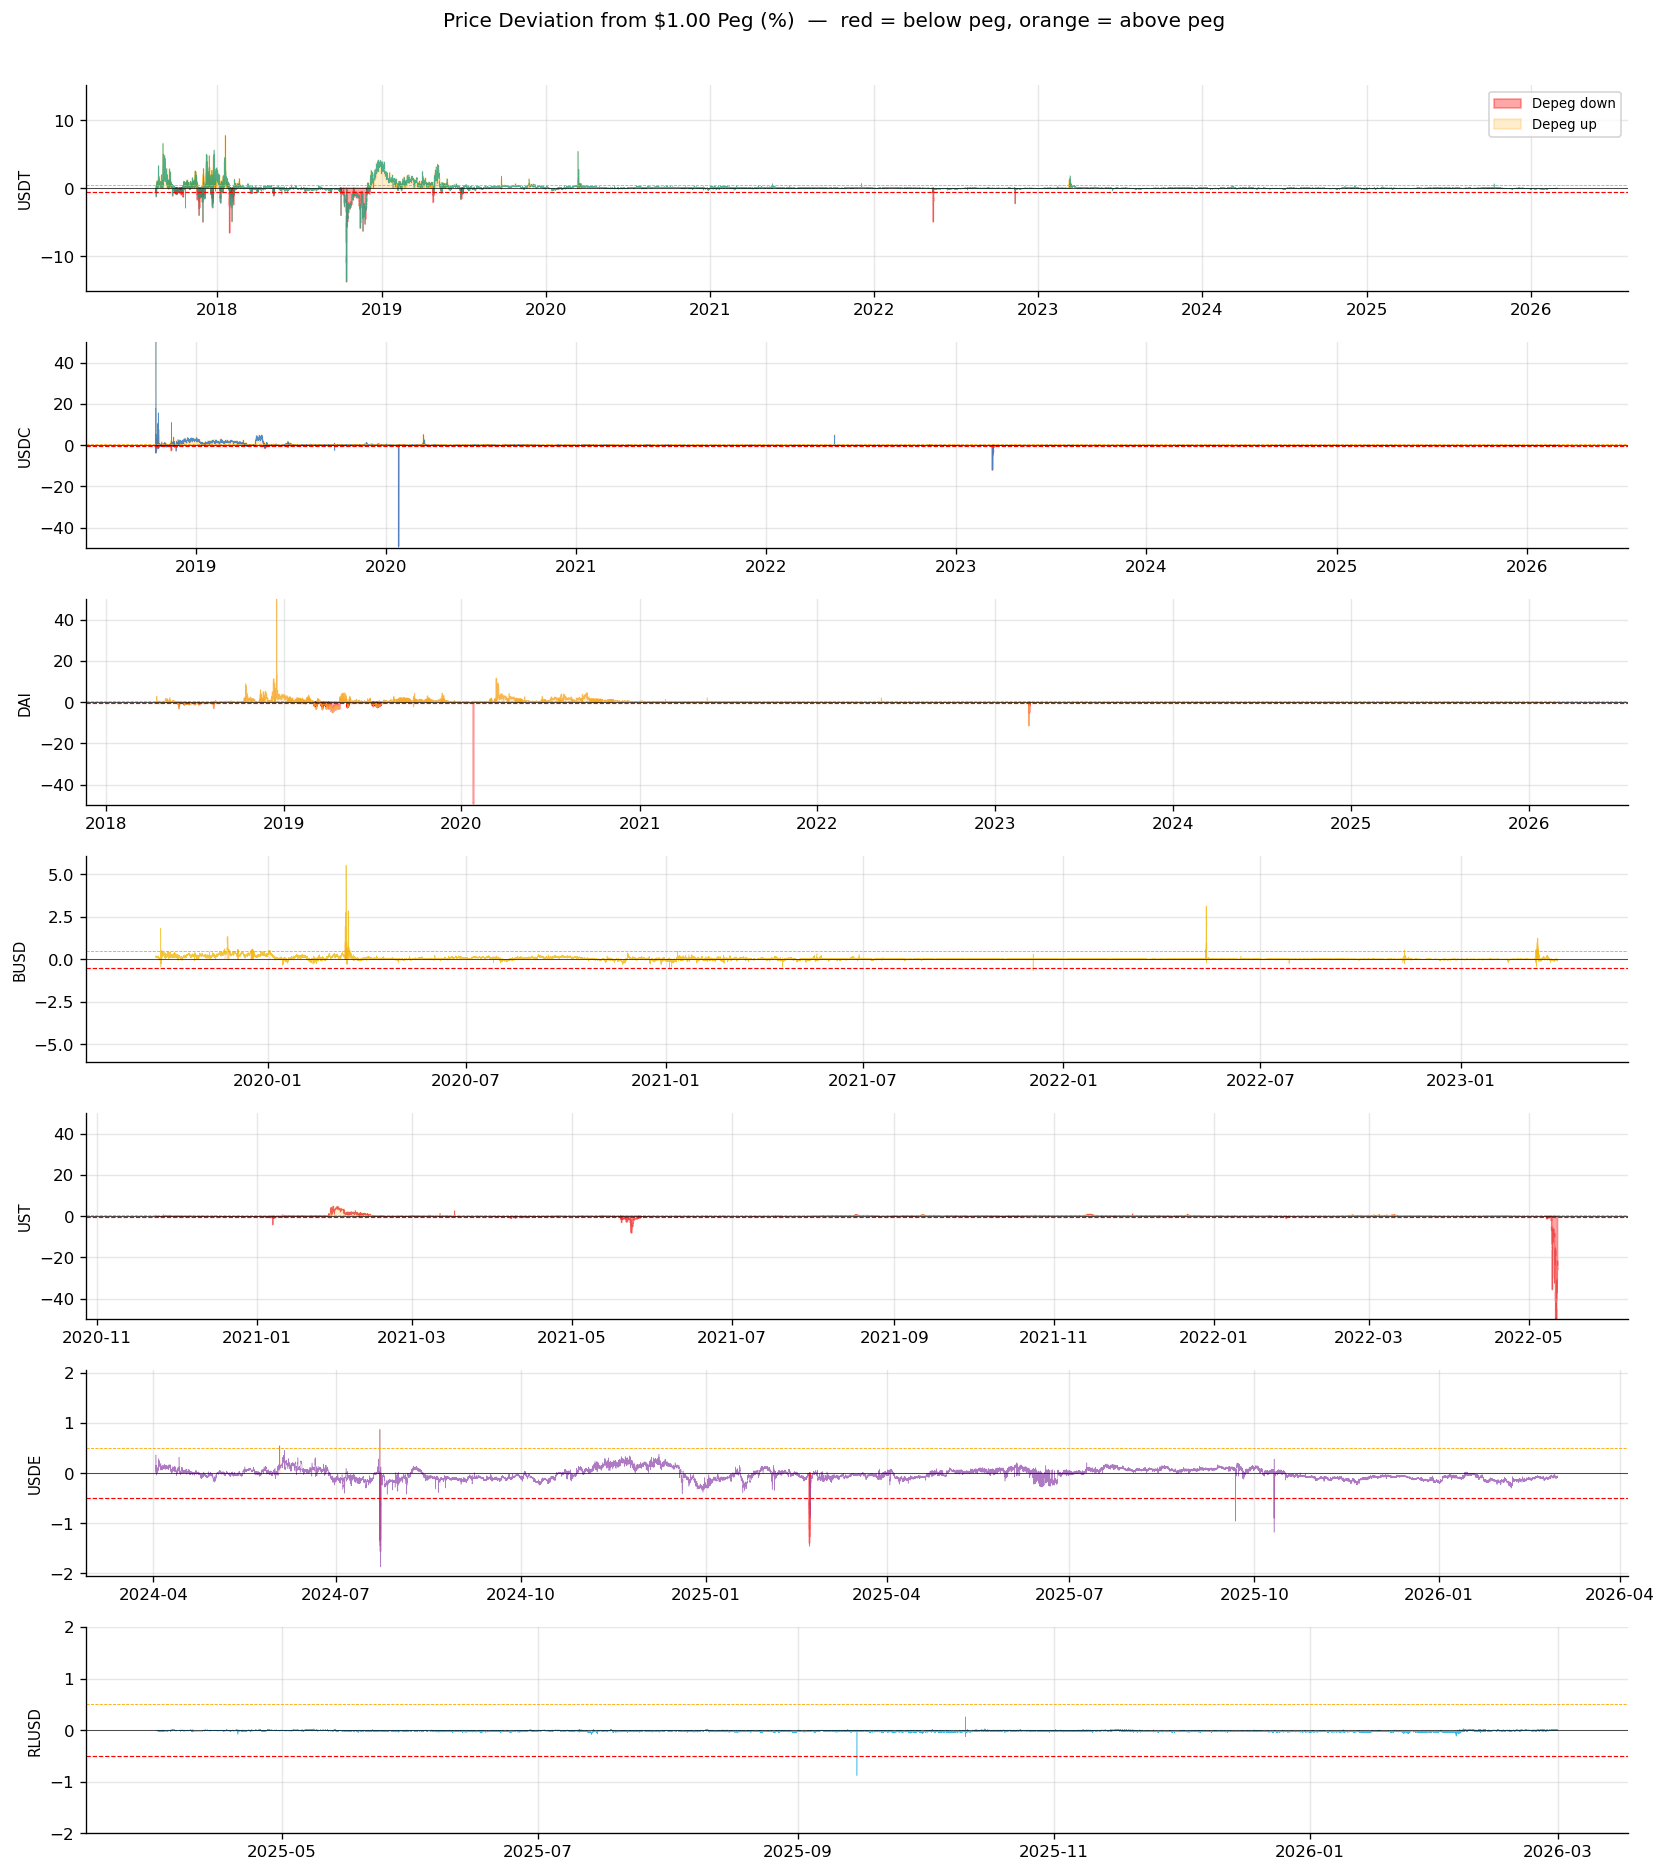

In [4]:
fig, axes = plt.subplots(len(COINS), 1, figsize=(14, 2.2*len(COINS)), sharex=False)

for ax, coin in zip(axes, COINS):
    df         = dfs[coin]
    pct        = df['price_dev'] * 100
    depeg_down = df['depeg_down'].fillna(0).astype(float)
    depeg_up   = ((df['depeg'].fillna(0).astype(float) == 1) & (depeg_down == 0)).astype(float)

    ax.plot(df.index, pct, lw=0.3, color=COLORS[coin], alpha=0.8)
    ax.fill_between(df.index, pct, 0, where=(depeg_down==1),
                    color='red', alpha=0.35, label='Depeg down')
    ax.fill_between(df.index, pct, 0, where=(depeg_up==1),
                    color='orange', alpha=0.2, label='Depeg up')
    ax.axhline(-0.5, color='red',    lw=0.7, ls='--')
    ax.axhline( 0.5, color='orange', lw=0.5, ls='--')
    ax.axhline( 0,   color='black',  lw=0.4)
    ax.set_ylabel(coin.upper(), fontsize=9)
    ymax = max(abs(pct.min()), abs(pct.max()))
    ax.set_ylim(-min(max(ymax*1.1, 2), 50), min(max(ymax*1.1, 2), 50))

axes[0].legend(fontsize=8, loc='upper right')
fig.suptitle('Price Deviation from $1.00 Peg (%)  —  red = below peg, orange = above peg',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 3. Downside vs Upside Depeg Rate Comparison

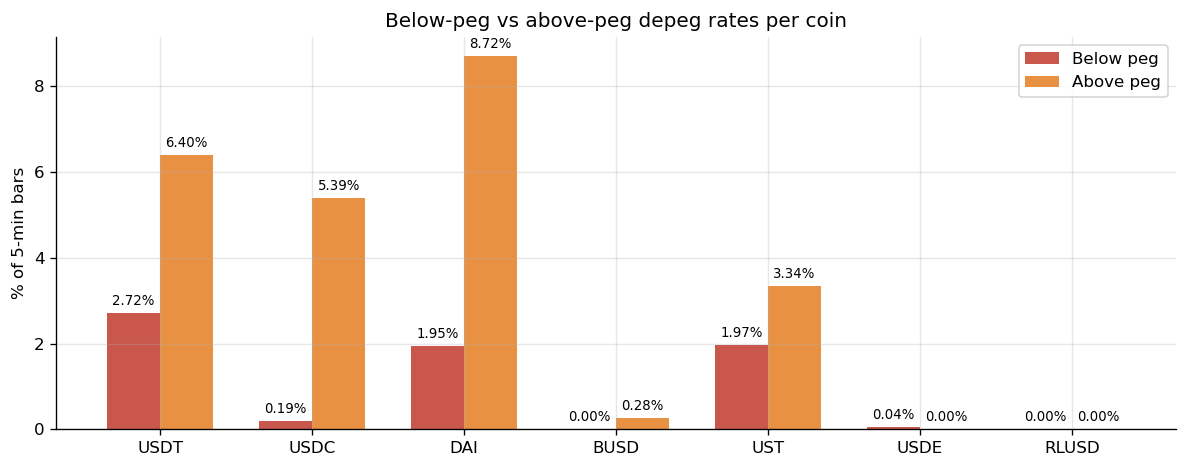

In [5]:
coins_list = list(COINS)
x = np.arange(len(coins_list))
w = 0.35

down_rates = [dfs[c]['depeg_down'].mean()*100 for c in coins_list]
up_rates   = [(dfs[c]['depeg'].fillna(0).astype(float) - dfs[c]['depeg_down'].fillna(0).astype(float)).clip(lower=0).mean()*100
              for c in coins_list]

fig, ax = plt.subplots(figsize=(10, 4))
bars_d = ax.bar(x - w/2, down_rates, w, label='Below peg',  color='#C0392B', alpha=0.85)
bars_u = ax.bar(x + w/2, up_rates,   w, label='Above peg',  color='#E67E22', alpha=0.85)
ax.bar_label(bars_d, fmt='%.2f%%', padding=3, fontsize=8)
ax.bar_label(bars_u, fmt='%.2f%%', padding=3, fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels([c.upper() for c in coins_list])
ax.set_ylabel('% of 5-min bars')
ax.set_title('Below-peg vs above-peg depeg rates per coin')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Downside Depeg Co-occurrence
When coin A is *below* peg, how often is coin B also below peg?

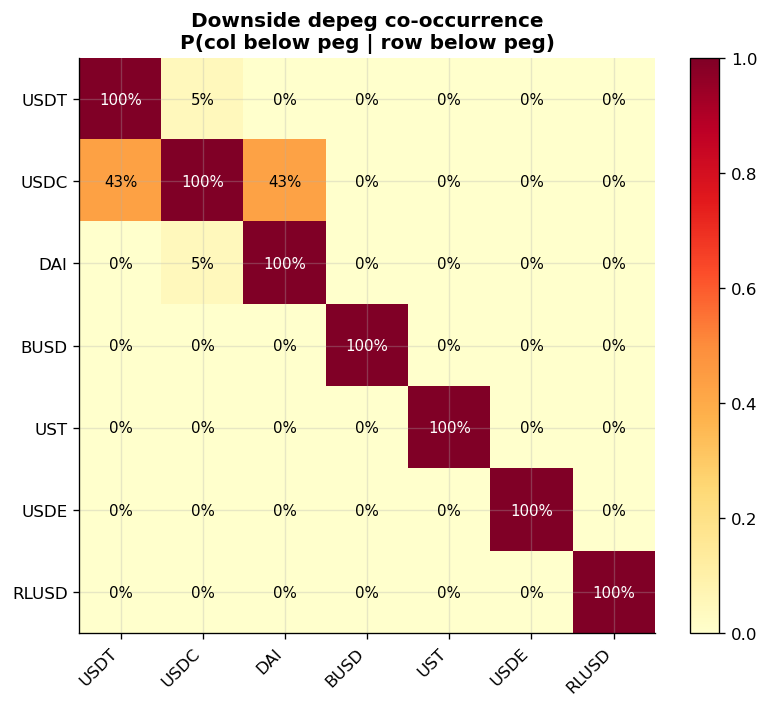

Notable co-occurrence (excluding diagonal, >5%):
  When USDC below peg → USDT also below peg 43% of the time
  When USDC below peg → DAI also below peg 43% of the time


In [6]:
dep_down_aligned = pd.concat(
    {c.upper(): dfs[c]['depeg_down'].fillna(0).astype(float) for c in COINS}, axis=1
)

coins_u  = list(dep_down_aligned.columns)
cooccur  = pd.DataFrame(index=coins_u, columns=coins_u, dtype=float)
for r in coins_u:
    for c in coins_u:
        if r == c:
            cooccur.loc[r, c] = 1.0
        else:
            pair = dep_down_aligned[[r, c]].dropna()
            n_r  = int((pair[r] == 1).sum())
            cooccur.loc[r, c] = float(((pair[r] == 1) & (pair[c] == 1)).sum()) / n_r if n_r > 0 else 0.0

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cooccur.values.astype(float), cmap='YlOrRd', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
m = len(coins_u)
ax.set_xticks(range(m)); ax.set_yticks(range(m))
ax.set_xticklabels(coins_u, rotation=45, ha='right')
ax.set_yticklabels(coins_u)
for i in range(m):
    for j in range(m):
        v = float(cooccur.iloc[i, j])
        ax.text(j, i, f'{v:.0%}', ha='center', va='center', fontsize=9,
                color='white' if v > 0.6 else 'black')
ax.set_title('Downside depeg co-occurrence\nP(col below peg | row below peg)', fontweight='bold')
plt.tight_layout()
plt.show()

print("Notable co-occurrence (excluding diagonal, >5%):")
for r in coins_u:
    for c in coins_u:
        v = float(cooccur.loc[r, c])
        if r != c and v > 0.05:
            print(f"  When {r} below peg \u2192 {c} also below peg {v:.0%} of the time")

## 5. Price Deviation Distribution — Below-Peg Tail
Left tail only. How far below $1.00 do coins go, and how often?

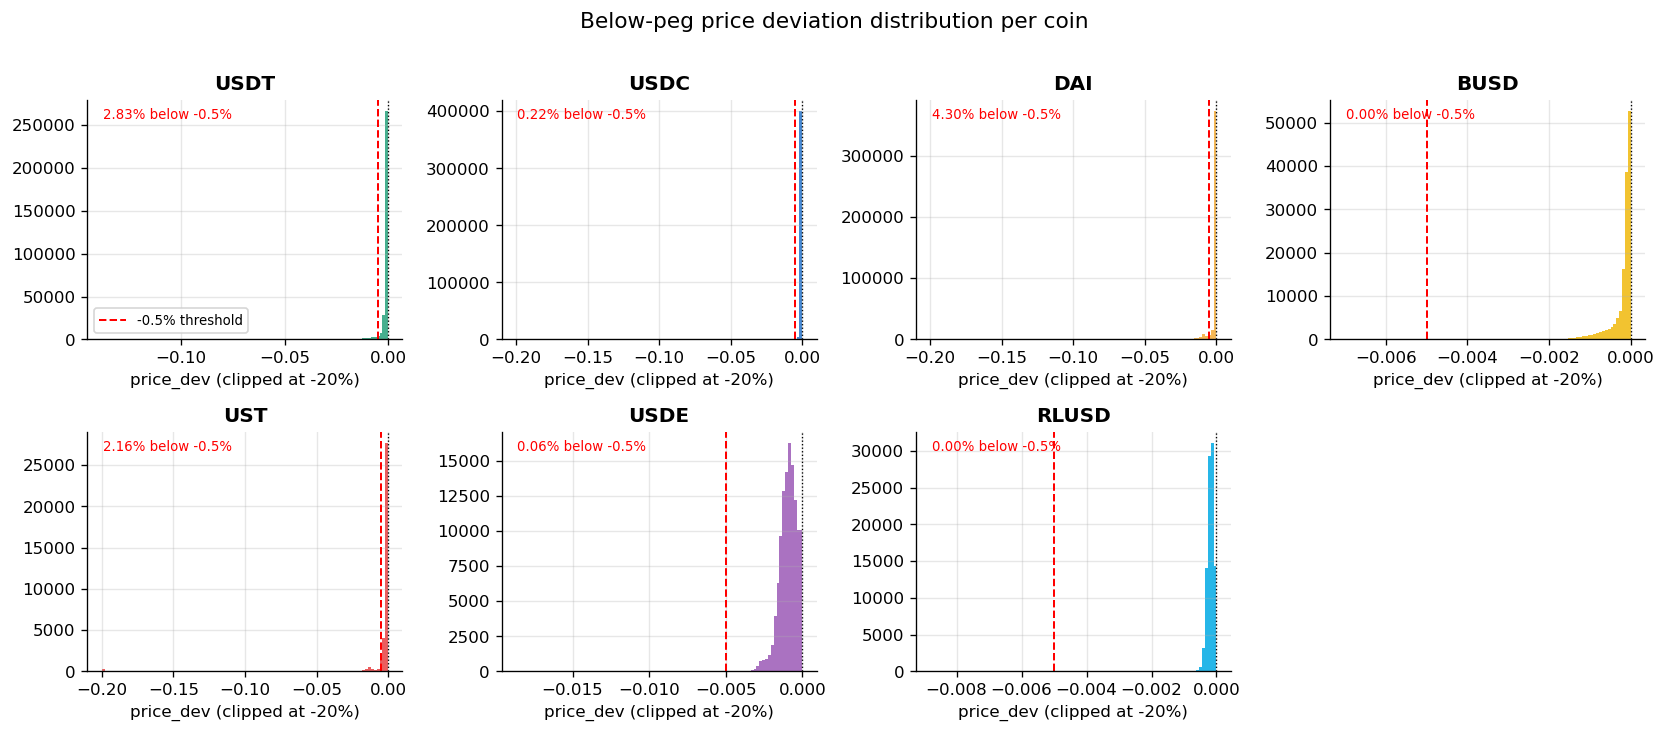

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharey=False)
axes = axes.flatten()

for ax, (coin, df) in zip(axes, dfs.items()):
    dev = df['price_dev'].dropna()
    below = dev[dev < 0]
    ax.hist(below.clip(-0.20, 0), bins=100, color=COLORS[coin], edgecolor='none', alpha=0.85)
    ax.axvline(-0.005, color='red', lw=1.2, ls='--', label='-0.5% threshold')
    ax.axvline(0,      color='black', lw=0.8, ls=':')
    ax.set_title(coin.upper(), fontweight='bold')
    ax.set_xlabel('price_dev (clipped at -20%)')
    pct_below = (dev < -0.005).mean()
    ax.text(0.05, 0.92, f'{pct_below:.2%} below -0.5%',
            transform=ax.transAxes, fontsize=8, color='red')

axes[0].legend(fontsize=8)
for ax in axes[len(dfs):]:
    ax.set_visible(False)

fig.suptitle('Below-peg price deviation distribution per coin', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 6. UST Collapse — May 2022
The canonical below-peg failure: algorithmic stablecoin spiral to near zero.

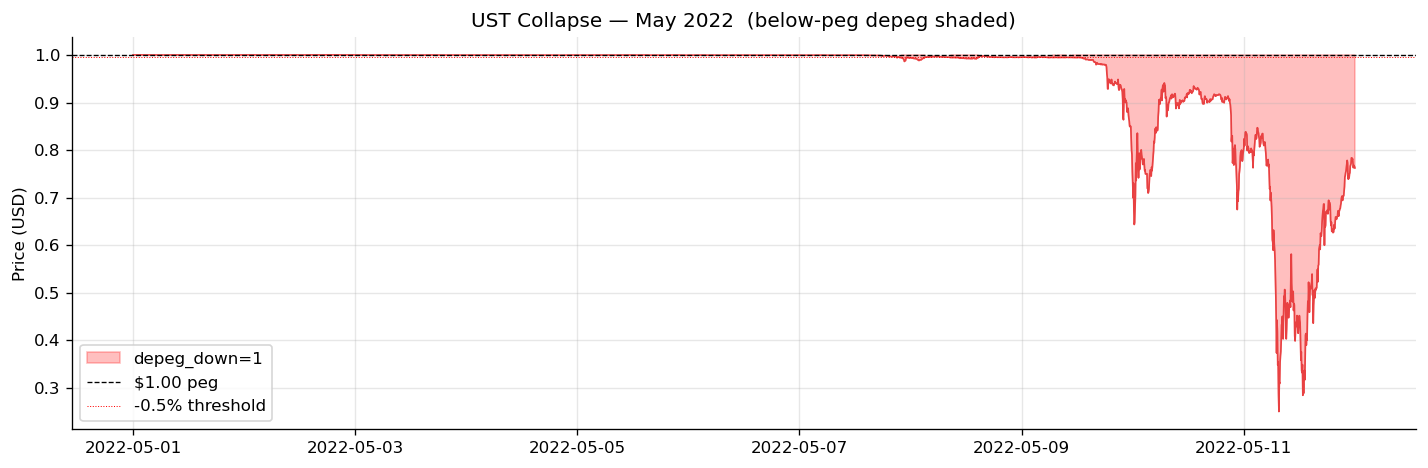

In [8]:
ust      = dfs['ust']
collapse = ust['2022-05-01':'2022-05-15']
depeg_d  = collapse['depeg_down'].fillna(0).astype(float)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(collapse.index, collapse['coinapi_close'], lw=1, color=COLORS['ust'])
ax.fill_between(collapse.index, collapse['coinapi_close'], 1,
                where=(depeg_d==1), color='red', alpha=0.25, label='depeg_down=1')
ax.axhline(1.0,   color='black', lw=0.8, ls='--', label='$1.00 peg')
ax.axhline(0.995, color='red',   lw=0.6, ls=':',  label='-0.5% threshold')
ax.set_title('UST Collapse — May 2022  (below-peg depeg shaded)')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.tight_layout()
plt.show()

## 7. USDC SVB Depeg — March 2023
Below-peg episode driven by $3.3B of Circle's reserves held at Silicon Valley Bank.

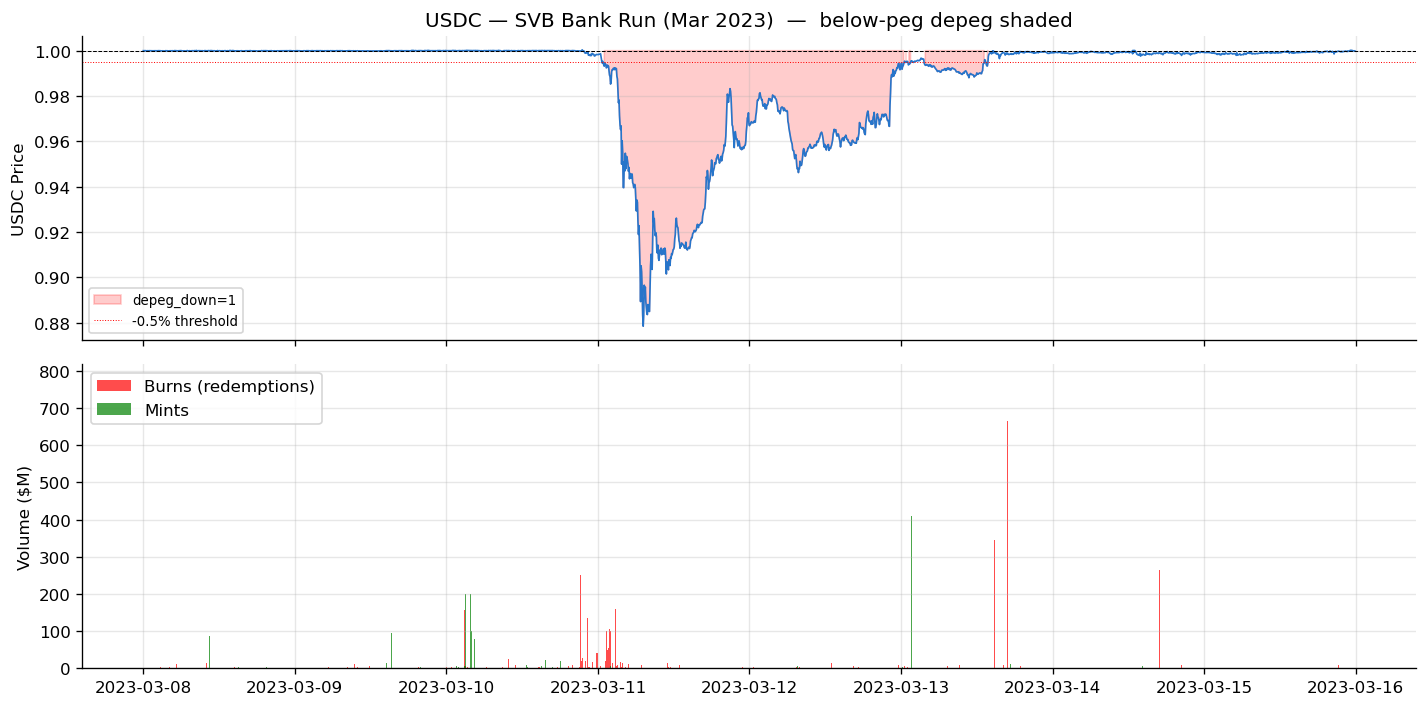

In [9]:
usdc  = dfs['usdc']
svb   = usdc['2023-03-08':'2023-03-15']
depeg_d = svb['depeg_down'].fillna(0).astype(float)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax1.plot(svb.index, svb['coinapi_close'], lw=1, color=COLORS['usdc'])
ax1.fill_between(svb.index, svb['coinapi_close'], 1,
                 where=(depeg_d==1), color='red', alpha=0.2, label='depeg_down=1')
ax1.axhline(1.0,   color='black', lw=0.6, ls='--')
ax1.axhline(0.995, color='red',   lw=0.6, ls=':', label='-0.5% threshold')
ax1.set_ylabel('USDC Price')
ax1.set_title('USDC — SVB Bank Run (Mar 2023)  —  below-peg depeg shaded')
ax1.legend(fontsize=8)

ax2.bar(svb.index, svb['burn_volume_usd']/1e6, width=0.003,
        color='red', alpha=0.7, label='Burns (redemptions)')
ax2.bar(svb.index, svb['mint_volume_usd']/1e6, width=0.003,
        color='green', alpha=0.7, label='Mints')
ax2.set_ylabel('Volume ($M)')
ax2.legend()

plt.tight_layout()
plt.show()

## 8. Macro Correlation — VIX vs Downside Depeg Rate

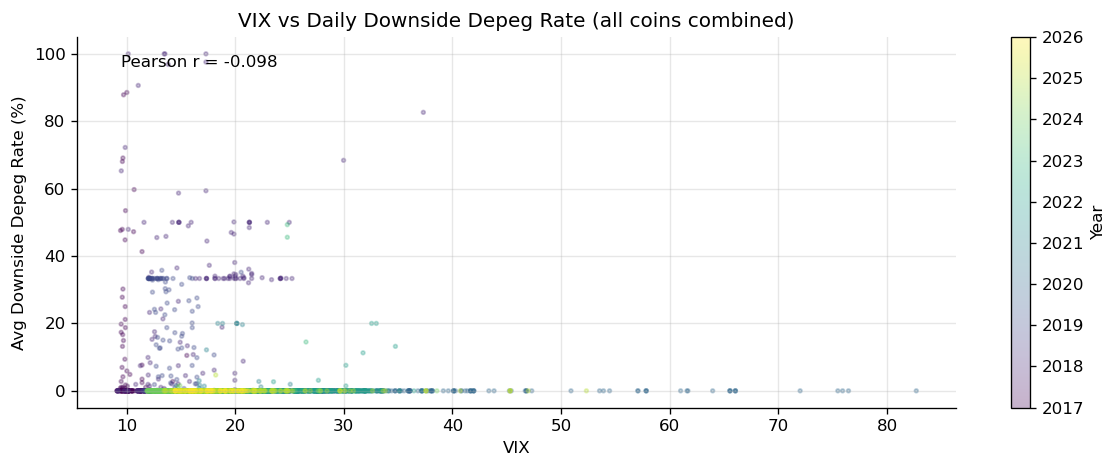

In [10]:
all_dfs = []
for coin in COINS:
    df = dfs[coin][['vix', 'depeg_down']].copy()
    all_dfs.append(df)

combined = pd.concat(all_dfs).sort_index()
daily = combined.resample('1D').agg({'vix': 'first', 'depeg_down': 'mean'}).dropna()

fig, ax = plt.subplots(figsize=(10, 4))
sc = ax.scatter(daily['vix'], daily['depeg_down']*100, alpha=0.3, s=5,
                c=daily.index.year, cmap='viridis')
plt.colorbar(sc, ax=ax, label='Year')
ax.set_xlabel('VIX')
ax.set_ylabel('Avg Downside Depeg Rate (%)')
ax.set_title('VIX vs Daily Downside Depeg Rate (all coins combined)')
corr = daily[['vix','depeg_down']].corr().iloc[0,1]
ax.text(0.05, 0.92, f'Pearson r = {corr:.3f}', transform=ax.transAxes, fontsize=10)
plt.tight_layout()
plt.show()

## 9. Label Distribution — Downside Forward-looking Horizons

In [11]:
label_cols = ['depeg_down', 'depeg_next_5min_down', 'depeg_next_30min_down',
              'depeg_next_1h_down', 'depeg_next_4h_down']

rows = []
for coin in COINS:
    df = dfs[coin]
    available = [c for c in label_cols if c in df.columns]
    row = {'Coin': coin.upper()}
    for col in available:
        row[col] = f"{df[col].mean():.2%}"
    rows.append(row)

pd.DataFrame(rows).set_index('Coin')

,depeg_down,depeg_next_5min_down,depeg_next_30min_down,depeg_next_1h_down,depeg_next_4h_down
Coin,,,,,
USDT,2.72%,2.72%,2.86%,2.97%,3.32%
USDC,0.19%,0.19%,0.23%,0.26%,0.41%
DAI,1.95%,1.95%,2.12%,2.23%,2.58%
BUSD,0.00%,0.00%,0.00%,0.00%,0.00%
UST,1.97%,1.97%,2.13%,2.24%,2.62%
USDE,0.04%,0.04%,0.08%,0.10%,0.17%
RLUSD,0.00%,0.00%,0.00%,0.00%,0.00%


## 10. On-chain & Curve Flows as Leading Indicators — Downside Only
Same signal elevation analysis as notebook 03, but onset rows are defined by `depeg_next_1h_down=1`.
A ratio > 1 means the flow signal is elevated before a *below-peg* depeg specifically.

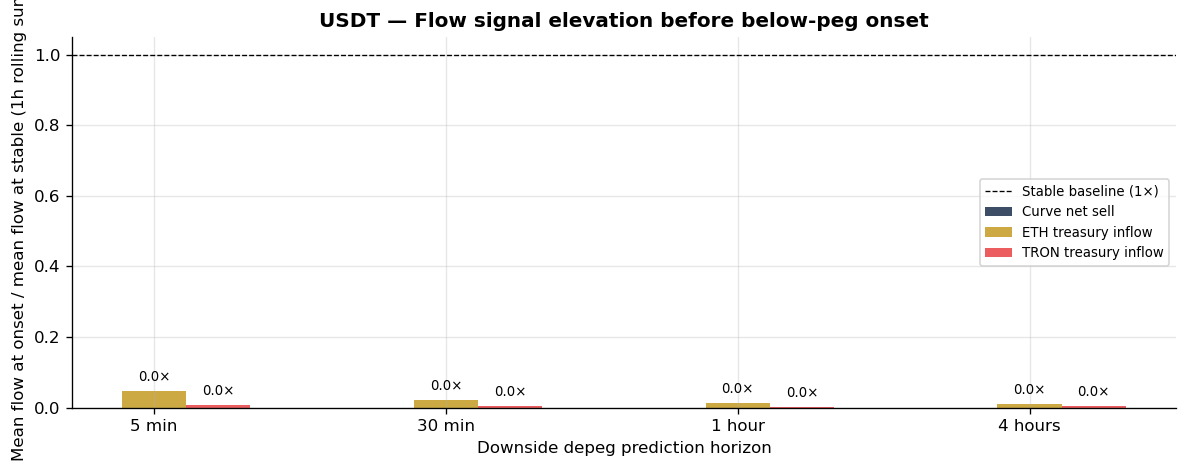

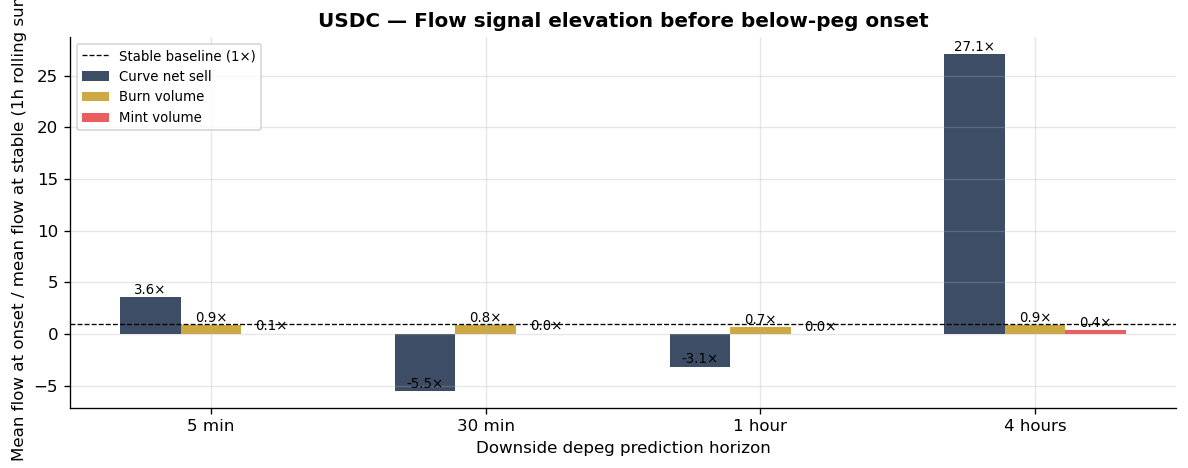

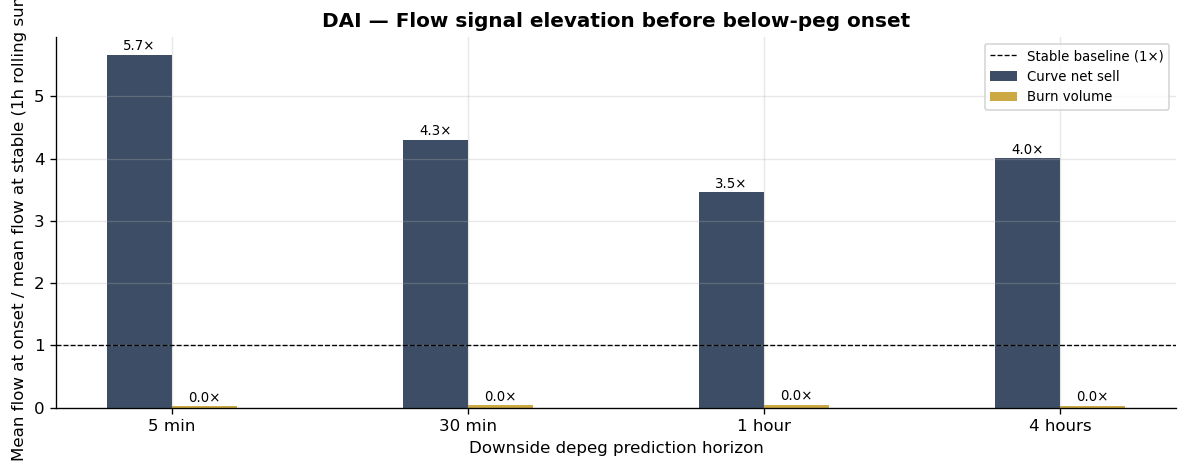

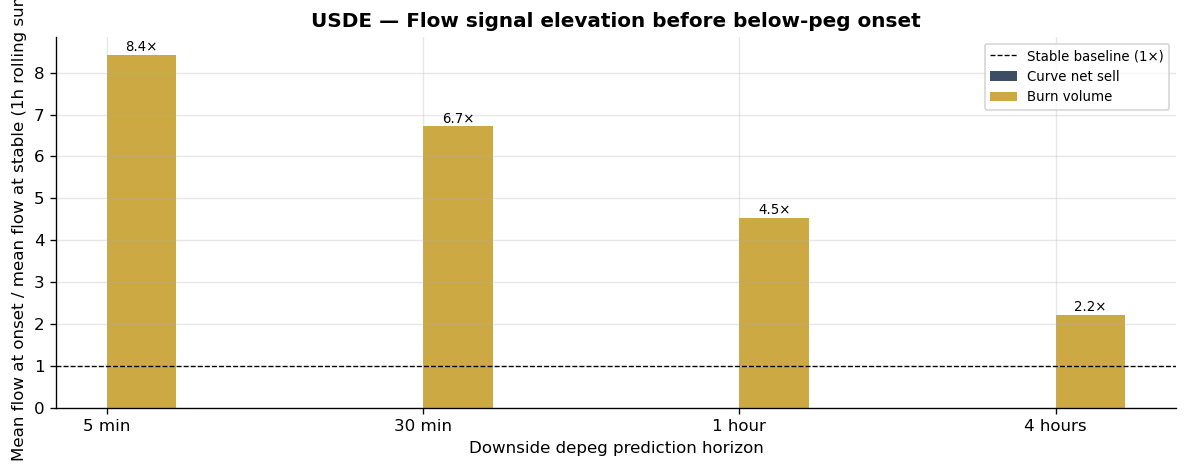

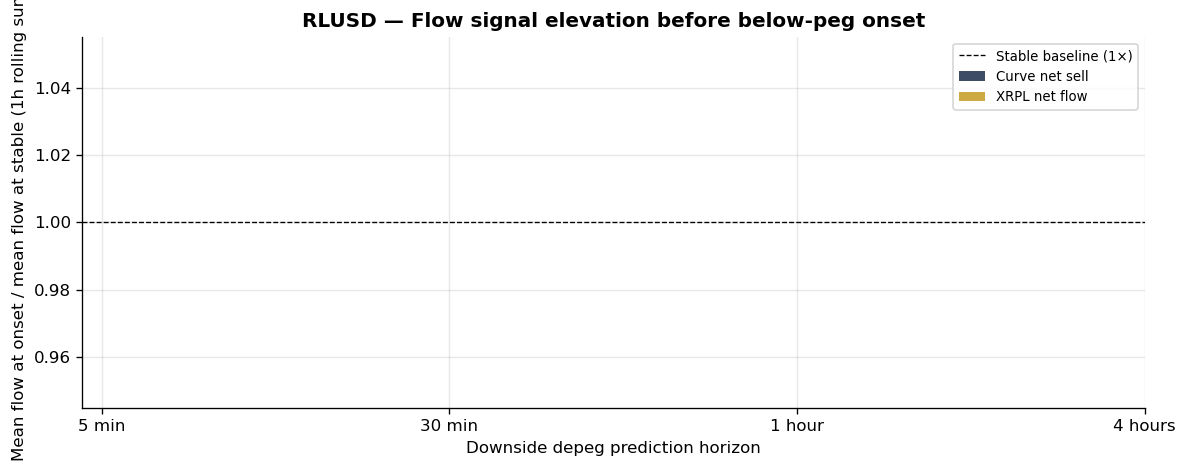

In [12]:
BARS_1H  = 12
HORIZONS_DOWN = [
    ("depeg_next_5min_down",  "5 min"),
    ("depeg_next_30min_down", "30 min"),
    ("depeg_next_1h_down",    "1 hour"),
    ("depeg_next_4h_down",    "4 hours"),
]

COIN_SIGNALS = {
    "usdt": [
        ("curve_3pool_usdt_net_sell_volume_usd", "Curve net sell"),
        ("treasury_inflow_volume_usd",           "ETH treasury inflow"),
        ("tron_treasury_inflow_volume_usd",      "TRON treasury inflow"),
    ],
    "usdc": [
        ("curve_3pool_usdc_net_sell_volume_usd", "Curve net sell"),
        ("burn_volume_usd",                      "Burn volume"),
        ("mint_volume_usd",                      "Mint volume"),
    ],
    "dai": [
        ("curve_3pool_dai_net_sell_volume_usd",  "Curve net sell"),
        ("burn_volume_usd",                      "Burn volume"),
    ],
    "usde": [
        ("curve_usde_usdc_usde_net_sell_volume_usd", "Curve net sell"),
        ("burn_volume_usd",                          "Burn volume"),
    ],
    "rlusd": [
        ("curve_rlusd_usdc_rlusd_net_sell_volume_usd", "Curve net sell"),
        ("xrpl_net_flow_usd",                          "XRPL net flow"),
    ],
}

x = np.arange(len(HORIZONS_DOWN))
bar_w = 0.22

for coin, signals in COIN_SIGNALS.items():
    df = dfs[coin].copy()
    avail = [(col, lbl) for col, lbl in signals if col in df.columns]
    if not avail:
        continue

    rolled = {lbl: df[col].rolling(BARS_1H, min_periods=1).sum() for col, lbl in avail}
    stable_mask = df["depeg_down"].fillna(0) == 0

    fig, ax = plt.subplots(figsize=(10, 4))
    colors = ["#1A2E4A", "#C49A22", "#E84142"]

    for k, (lbl, color) in enumerate(zip(rolled, colors)):
        ratios = []
        for h_col, h_label in HORIZONS_DOWN:
            if h_col not in df.columns:
                ratios.append(float("nan"))
                continue
            h = df[h_col].astype(float)
            onset  = rolled[lbl][stable_mask & (h == 1)]
            stable = rolled[lbl][stable_mask & (h == 0)]
            stable_mean = stable.mean()
            ratios.append(onset.mean() / stable_mean if stable_mean > 0 else float("nan"))

        offset = (k - len(avail) / 2 + 0.5) * bar_w
        bars = ax.bar(x + offset, ratios, bar_w, label=lbl, color=color, alpha=0.85)
        for bar, v in zip(bars, ratios):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                        f"{v:.1f}\u00d7", ha="center", va="bottom", fontsize=8)

    ax.axhline(1, color="black", lw=0.8, ls="--", label="Stable baseline (1\u00d7)")
    ax.set_xticks(x)
    ax.set_xticklabels([h for _, h in HORIZONS_DOWN])
    ax.set_xlabel("Downside depeg prediction horizon")
    ax.set_ylabel("Mean flow at onset / mean flow at stable (1h rolling sum)")
    ax.set_title(f"{coin.upper()} \u2014 Flow signal elevation before below-peg onset", fontweight="bold")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

## 11. Lead Time Curves — Downside Onset
How far in advance do on-chain flows rise before a *below-peg* depeg?

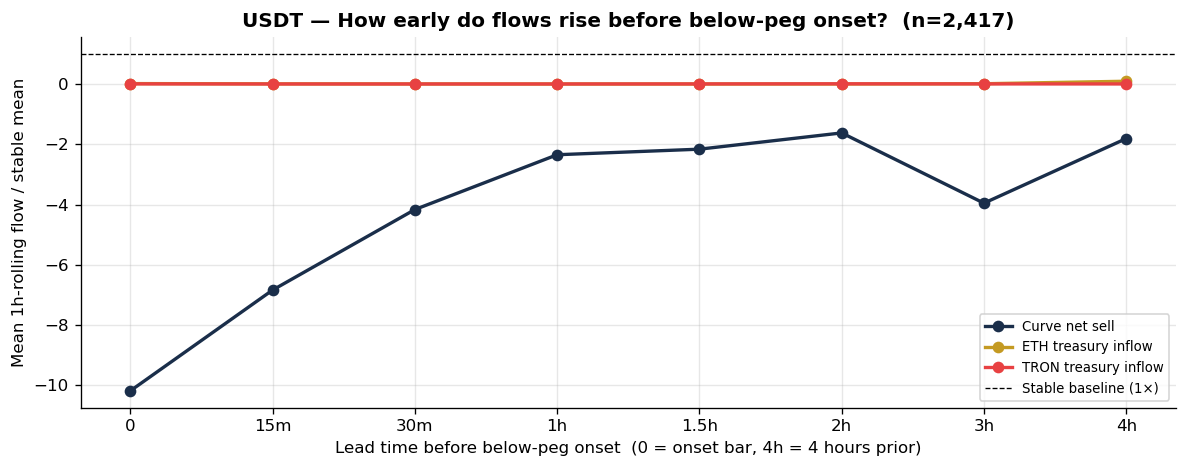

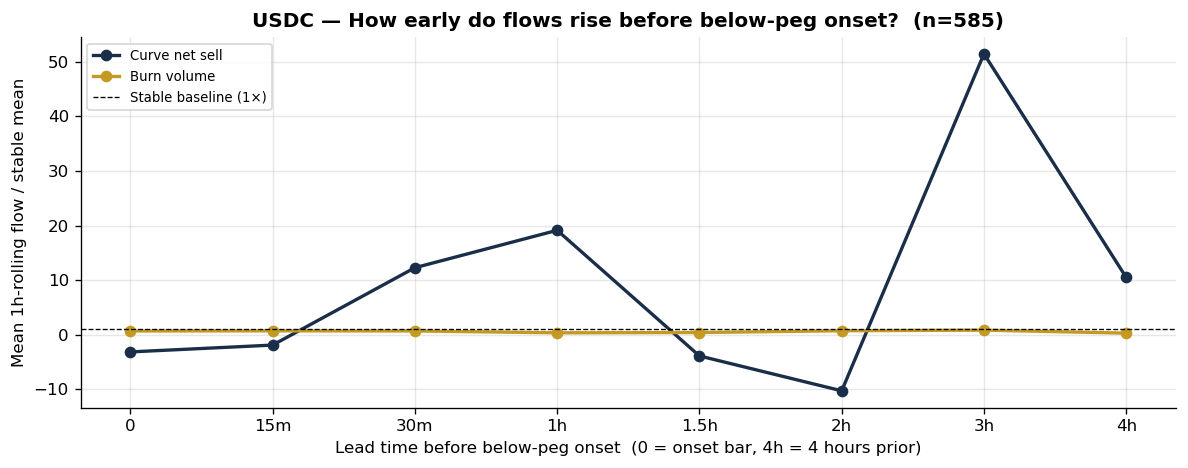

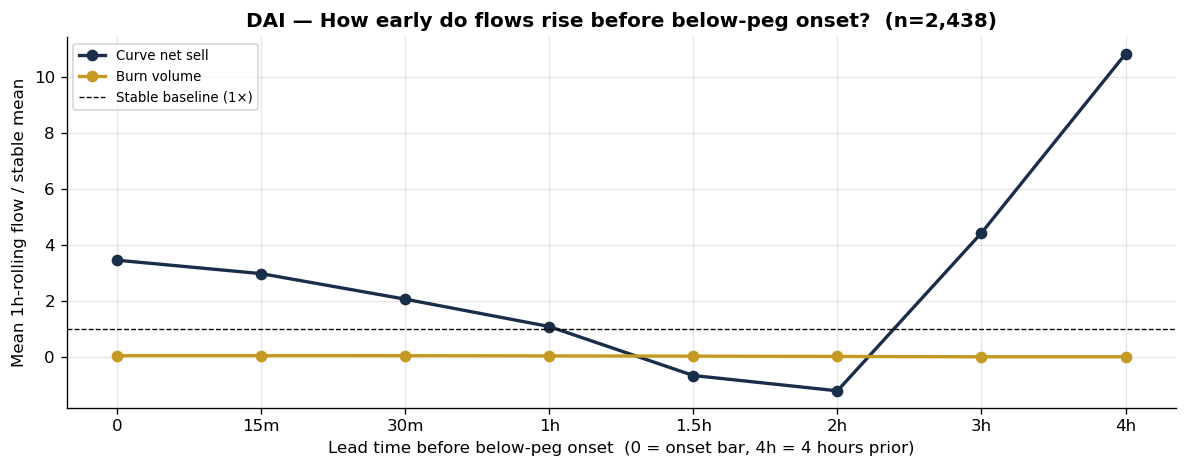

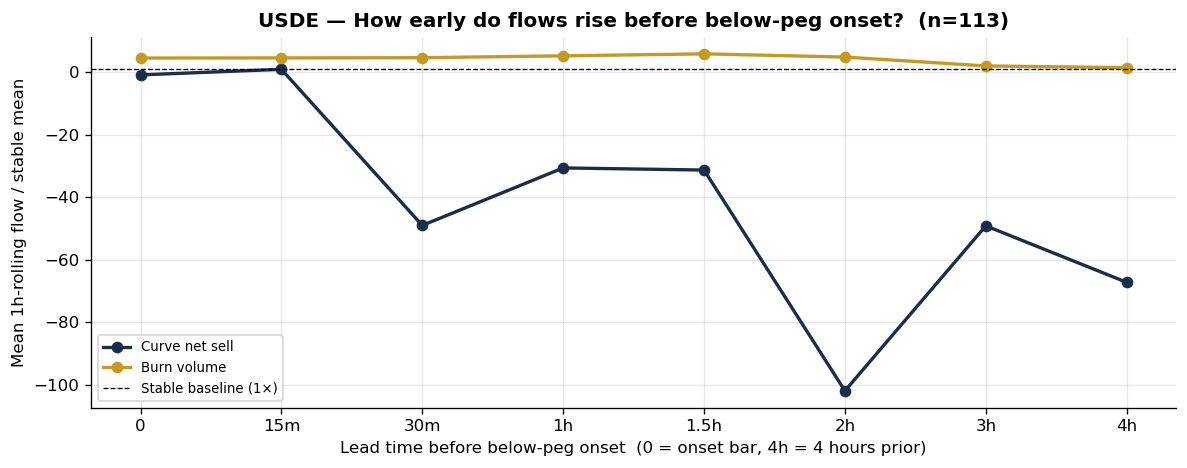

RLUSD: only 0 downside onset rows — skipping
Interpretation guide:
  ratio >> 1 at large lead time  → long early-warning window
  ratio >> 1 only at 0–15min     → very short-leading, near-coincident with depeg
  ratio ≈ 1 throughout            → signal not predictive at 1h rolling resolution


In [13]:
LEAD_BARS   = [0, 3, 6, 12, 18, 24, 36, 48]
LEAD_LABELS = ["0", "15m", "30m", "1h", "1.5h", "2h", "3h", "4h"]

LEAD_SIGNALS = {
    "usdt": [
        ("curve_3pool_usdt_net_sell_volume_usd", "Curve net sell",       "#1A2E4A"),
        ("treasury_inflow_volume_usd",           "ETH treasury inflow",  "#C49A22"),
        ("tron_treasury_inflow_volume_usd",      "TRON treasury inflow", "#E84142"),
    ],
    "usdc": [
        ("curve_3pool_usdc_net_sell_volume_usd", "Curve net sell", "#1A2E4A"),
        ("burn_volume_usd",                      "Burn volume",    "#C49A22"),
    ],
    "dai": [
        ("curve_3pool_dai_net_sell_volume_usd",  "Curve net sell", "#1A2E4A"),
        ("burn_volume_usd",                      "Burn volume",    "#C49A22"),
    ],
    "usde": [
        ("curve_usde_usdc_usde_net_sell_volume_usd", "Curve net sell", "#1A2E4A"),
        ("burn_volume_usd",                          "Burn volume",    "#C49A22"),
    ],
    "rlusd": [
        ("curve_rlusd_usdc_rlusd_net_sell_volume_usd", "Curve net sell",  "#1A2E4A"),
        ("xrpl_net_flow_usd",                          "XRPL net flow",   "#C49A22"),
    ],
}

for coin, signals in LEAD_SIGNALS.items():
    df = dfs[coin].copy()
    onset_mask  = (df["depeg_down"].fillna(0) == 0) & (df["depeg_next_1h_down"].fillna(0).astype(float) == 1)
    stable_mask = (df["depeg_down"].fillna(0) == 0) & (df["depeg_next_1h_down"].fillna(0).astype(float) == 0)

    n_onset = onset_mask.sum()
    if n_onset < 50:
        print(f"{coin.upper()}: only {n_onset} downside onset rows \u2014 skipping")
        continue

    fig, ax = plt.subplots(figsize=(10, 4))
    plotted = 0

    for col, lbl, color in signals:
        if col not in df.columns:
            continue
        signal = df[col].rolling(BARS_1H, min_periods=1).sum()
        stable_mean = signal[stable_mask].mean()
        if stable_mean == 0:
            continue

        ratios = []
        for k in LEAD_BARS:
            shifted = signal.shift(k)
            ratios.append(shifted[onset_mask].mean() / stable_mean)

        ax.plot(range(len(LEAD_BARS)), ratios, "o-", label=lbl, color=color, lw=2, ms=6)
        plotted += 1

    if plotted == 0:
        plt.close()
        print(f"{coin.upper()}: no valid signals \u2014 skipping")
        continue

    ax.axhline(1, color="black", lw=0.8, ls="--", label="Stable baseline (1\u00d7)")
    ax.set_xticks(range(len(LEAD_BARS)))
    ax.set_xticklabels(LEAD_LABELS)
    ax.set_xlabel("Lead time before below-peg onset  (0 = onset bar, 4h = 4 hours prior)")
    ax.set_ylabel("Mean 1h-rolling flow / stable mean")
    ax.set_title(f"{coin.upper()} \u2014 How early do flows rise before below-peg onset?  (n={n_onset:,})",
                 fontweight="bold")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

print("Interpretation guide:")
print("  ratio >> 1 at large lead time  \u2192 long early-warning window")
print("  ratio >> 1 only at 0\u201315min     \u2192 very short-leading, near-coincident with depeg")
print("  ratio \u2248 1 throughout            \u2192 signal not predictive at 1h rolling resolution")

## 12. Next Step
Run `04_feature_engineering.ipynb` to build rolling-window features per coin.
The downside targets (`depeg_next_1h_down`, etc.) are available as alternative modeling targets alongside the symmetric `depeg_next_1h`.